# ODE symmetry detection examples

The purpose of this notebook is to demonstrate the capabilities of the symmetry-detection algorithm on 
several ODE examples. The ODEs are numerically integrated to generate synthetic trajectories, and lifted 
into the first order Jet-Space. This emmbedding can be computed analytically, using previous knowledge of
the equation, or by numerically differentiating the trajectories, which is the more realistic use case. 

Workflow:

0. Read args: Arguments are read from CLI or `defaults.py`. CLI arguments overrides defaults.

1. Trajectory generation: Select `ODE` and `method`, or use defaults. All other defaults can be overriden by setting the respective       variables.

2. Embedding: Choose the embedding scenario. For groud truth testing set `analytic_derivative` and `analytic_normal` to `True`. To test validity of the algorithm end to end set both to `False`.

3. Symmetry detection: Choose a basis by setting `BASIS_TYPE` and `PARAM_RANGE` or `PARAM_LIST`. Choose if you would like to find symmetries in characteristic form by setting `characteristic=True`. Run the symmetry-detection algorithm. The algorithm assumes that there will be a steep drop in the singuar value spectrum, after which all singular values will correspond to null directions. The associated right singular vectors are the coefficients of the basis function expansion of the found infinitesimal symmetries.

## 1. Trajectory generation

Select the ODE example you would like to test. Uses the package-wide defaults for the chosen ODE or manually set simulation variables.

          ODE Configuration — BERNOULLI          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]                 │
│ Resolution       │ 3000 points/trajectory     │
│ Trajectory Count │ 1000 initial conditions    │
│ IC Range         │ [0.75 ... 2.00]            │
│ Integrator       │ DOP853                     │
│ Tolerance        │ rtol=1.0e-12, atol=1.0e-12 │
└──────────────────┴────────────────────────────┘

Constructing embedding with numerical derivative


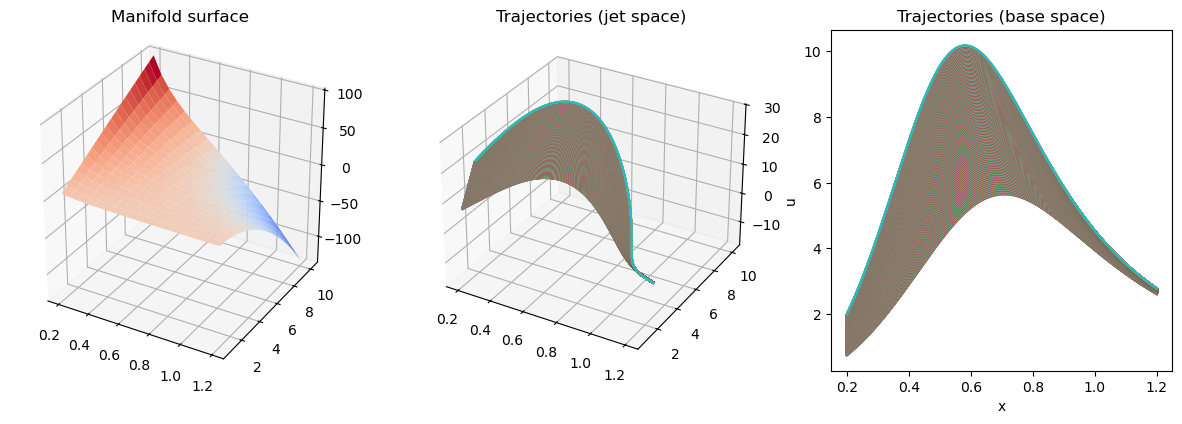

In [21]:
import argparse

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker

from symmetry_detection import data_matrices as dm
from symmetry_detection import generate_trajectories as gtr
from symmetry_detection import manifold as mfd
from symmetry_detection import plotting as plot
from symmetry_detection import reporting as rpt
from symmetry_detection import solver

%matplotlib inline

# --- ODE choice & integration method ---
# One of gtr.ODES.keys(): "bernoulli", "rational", "riccati", "scaling", "abel"
ODE = "bernoulli"
method="DOP853"
analytic_derivative = False

# Set the tolerances for the ODE solver
rtol = 1e-12
atol = 1e-12

# Combine default with CLI arguments and override with user-specified values.
ode_args = argparse.Namespace(
    ode=ODE, start=None, end=None, initial_conditions=None, num_points=None, method=method,
    rtol=None, atol=None,
)
ode_args = gtr.resolve_ode_args(ode_args)

X = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=ode_args.initial_conditions,
    num_points=ode_args.num_points,
    method=method,
    rtol=rtol,
    atol=atol,
    analytic_derivative=analytic_derivative,
    window_length=5,
)

# Stack trajectories into a (num_dim, num_points * num_traj) array
X_stacked = gtr.concatenate_trajectories(X)

"""
    Plot trajectories and embedding
"""

# Create a grid of points over the domain of the ODE
res = 20
x_min, x_max = np.min(X[:, 0, :]), np.max(X[:, 0, :])
u_min, u_max = np.min(X[:, 1, :]), np.max(X[:, 1, :])
X_grid = np.linspace(x_min, x_max, res)
U_grid = np.linspace(u_min, u_max, res)
X_grid, U_grid = np.meshgrid(X_grid, U_grid)
P_grid = gtr.ODES[ode_args.ode](X_grid, U_grid)
p_grid_min, p_grid_max = np.min(P_grid), np.max(P_grid)

# Manifold surface, jet-space trajectories, and base space trajectories side by side
manifold_fig = plt.figure(figsize=(12, 4))
ax0 = manifold_fig.add_subplot(131, projection='3d')
ax1 = manifold_fig.add_subplot(132, projection='3d')
ax2 = manifold_fig.add_subplot(133)

ax0.set_aspect('equal')
ax0.plot_surface(X_grid, U_grid, P_grid, cmap='coolwarm')
ax0.set_title("Manifold surface")

ax2.set_box_aspect(1)

for trajectory in X:
    ax1.plot(trajectory[0, :], trajectory[1, :], trajectory[2, :])
    ax2.plot(trajectory[0, :], trajectory[1, :])

ax1.set_title("Trajectories (jet space)")
ax2.set_title("Trajectories (base space)")
ax2.set_xlabel("x")
ax2.set_ylabel("u")

manifold_fig.tight_layout()

## 2. Normal field computation.

Toggle `analytic_normal` above to choose between:

- **`True`**: the exact normal field `N = (-f_x, -f_u, 1)`, differentiated analytically from the
  known right-hand side `f(x, u)` (`gtr.NORMALS[ode_args.ode]`).
- **`False`**: `mfd.estimate_normal_field`, a purely data-driven estimate of `N` from the
  multi-trajectory point cloud alone (no knowledge of `f`). A single trajectory only samples the
  curve `u(x)`; differentiating `u_x` along it gives one equation (`u_xx = f_x + u_x f_u`) in the
  two unknowns `f_x, f_u`, so recovering them separately needs variation in `u` at (approximately)
  fixed `x` — i.e. neighboring trajectories, not just further points along the same one. Because
  every trajectory shares the same `x` grid, neighborhoods in `(x, u)` can be built by plain
  index-slicing in `(trajectory, point)` space, with no nearest-neighbor search — see `manifold.py`
  for details.

  The trajectories/points at the edge of this index window only get one-sided, structurally less
  reliable gradient estimates, so `normal_window=(di, dj)` worth of them are always discarded;
  `normal_boundary_margin` optionally discards *additional* trajectories/points beyond that
  minimum (e.g. to use a wide window for a good fit while only trusting/reporting a smaller core
  region). `normal_window`/`normal_degree`/`normal_boundary_margin` only matter when
  `analytic_normal=False`.

`subsample_normal_field` is a **separate preprocessing step applied before symmetry detection,
regardless of `analytic_normal`**: it lets you compute the normal field (analytic or numeric) from
a *dense* point cloud (many trajectories/points — density is what `estimate_normal_field`
specifically needs to separate `f_x` from `f_u`, though a dense analytic field costs nothing extra
either), but feed a much smaller, evenly-spaced subset into the symmetry-detection SVD below
(`mfd.subsample_trajectories`) — the SVD/`G_matrix` step works well, and stays cheap, with
relatively few points, so there's no reason to hand it more than it needs.

**This cell overwrites `X_stacked` with the resulting (cropped and/or subsampled) subset**
whenever `analytic_normal=False` and/or `subsample_normal_field=True`, so everything downstream
(SVD, plots) only ever sees points that stay column-aligned with `N`.

estimate_normal_field: kept 998/1000 trajectories and 2998/3000 points/trajectory after discarding the boundary (window=(1, 1), degree=1, boundary_margin=0, max local-fit condition number=1.20e+05).
subsample_trajectories: kept 10 trajectories and 100 points/trajectory for symmetry detection (2992004 -> 1000 points fed into G_matrix/solve_svd; the dense numeric normal field above is still what was computed before subsampling).
X_stacked has been overwritten with this (cropped/subsampled) subset so it stays column-aligned with N for everything downstream.


Text(0.5, 0.92, 'Numeric (data-driven) normal field')

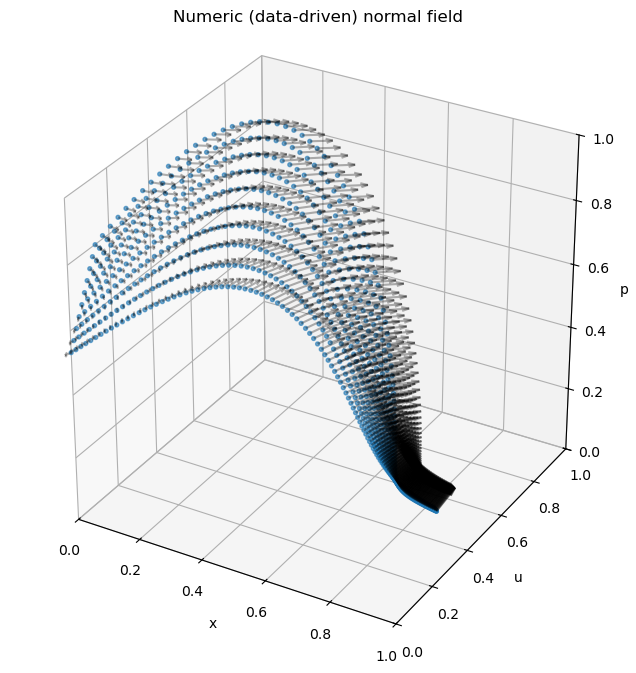

In [ ]:
# Always start from the full, untrimmed X so this cell is safe to re-run
# (e.g. after flipping analytic_normal) without re-running cell 2.
# X_dense/N_dense are built here in the *unflattened* (num_traj, ..., num_points)
# shape regardless of analytic_normal, so that subsampling below is a single
# preprocessing step shared by both the analytic and numeric normal fields,
# not something only the numeric path gets.
analytic_normal = False
normal_window = (1, 1)
normal_degree = 1
normal_boundary_margin = 0  # extra trajectories/points to discard beyond window/di,dj

subsample_normal_field = True
subsample_num_traj = 10    # e.g. 6 - None keeps all (post-boundary-discard) trajectories
subsample_num_points = 100   # e.g. 100 - None keeps all points

if analytic_normal:
    X_dense = X
    N_dense = gtr.NORMALS[ode_args.ode](X[:, 0, :], X[:, 1, :])
else:
    normal_est = mfd.estimate_normal_field(
        X, window=normal_window, degree=normal_degree,
        discard_boundary=True, boundary_margin=normal_boundary_margin,
    )
    X_dense, N_dense = normal_est.apply(X), normal_est.N
    print(
        f"estimate_normal_field: kept {N_dense.shape[1]}/{X.shape[0]} trajectories and "
        f"{N_dense.shape[2]}/{X.shape[2]} points/trajectory after discarding the boundary "
        f"(window={normal_window}, degree={normal_degree}, "
        f"boundary_margin={normal_boundary_margin}, "
        f"max local-fit condition number={np.nanmax(normal_est.cond):.2e})."
    )

# Subsampling is a preprocessing step before symmetry detection, independent
# of how the normal field itself was computed: use ALL of X (many
# trajectories/points) to get a good normal field above, but feed only a
# smaller, evenly spaced subset into the symmetry-detection linear algebra.
if subsample_normal_field:
    n_before = X_dense.shape[0] * X_dense.shape[2]
    X_dense, N_dense = mfd.subsample_trajectories(
        X_dense, N_dense, num_traj=subsample_num_traj, num_points=subsample_num_points,
    )
    n_after = X_dense.shape[0] * X_dense.shape[2]
    print(
        f"subsample_trajectories: kept {X_dense.shape[0]} trajectories and "
        f"{X_dense.shape[2]} points/trajectory for symmetry detection "
        f"({n_before} -> {n_after} points fed into G_matrix/solve_svd; the "
        f"{'analytic' if analytic_normal else 'dense numeric'} normal field above is "
        f"still what was computed before subsampling)."
    )

X_stacked = gtr.concatenate_trajectories(X_dense)
N = N_dense.reshape(3, -1)
if not analytic_normal or subsample_normal_field:
    print(
        "X_stacked has been overwritten with this (cropped/subsampled) subset so it "
        "stays column-aligned with N for everything downstream."
    )

fig_normal = plt.figure(figsize=(8,8))
ax_normal = fig_normal.add_subplot(projection='3d')

plot.scaled_3D_quiver(X_stacked, N, mode="normal", ax=ax_normal)
ax_normal.set_title("Analytic normal field" if analytic_normal else "Numeric (data-driven) normal field")

## 3. Symmetry detection

(equivalent to `examples/run_odes_demo.py`)

Change `BASIS_TYPE`, `PARAM_RANGE`, or `PARAM_LIST` below and re-run from here
— the trajectories generated above are reused as-is. This first solves the
SVD; it does **not** decide which singular value(s) are "small" or which one
to reconstruct from — that's a separate, explicit choice made further down,
once you can see the results. The `characteristic` variable determines whether
we look for a characteristic or regular point symmetry.

Estimated null-space dimension: 1
Small singular value indices: [17]


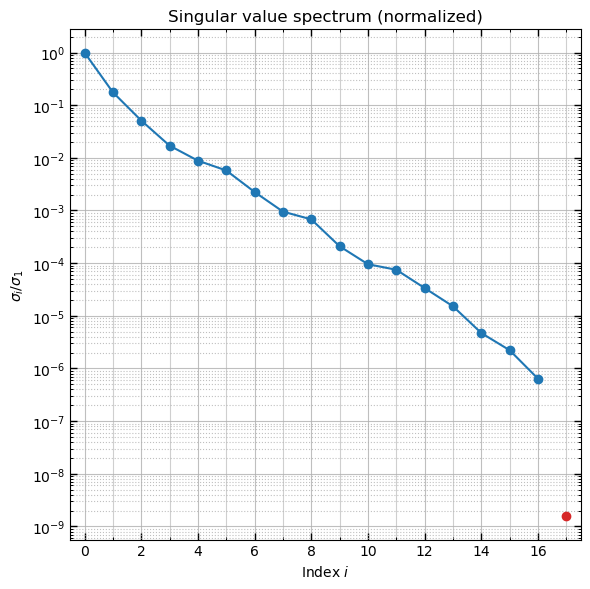

In [14]:
# --- Basis function family ---
# "monomial" or "chebyshev" (see symmetry_detection.basis_functions.BASIS_FUNCTIONS)
BASIS_TYPE = "monomial"
characteristic = False;

# --- Basis elements: pick a range OR an explicit list, exactly like the CLI's
# --param_range / --param_list flags (see data_matrices.resolve_basis_args).
# PARAM_LIST always overrides PARAM_RANGE when it is not None.
PARAM_RANGE = (0,2)  # all (m, n) pairs with m, n in 0..3
PARAM_LIST = None #[(0,0), (1,0), (-2,2)]    # e.g. [(0, 0), (1, 0), (0, 1), (2, 1)] to pick elements individually
sv_ratio = 10

# Resolve basis parameters the same way the CLI does: PARAM_LIST overrides
# PARAM_RANGE, and any still-missing field falls back to symmetry_detection.defaults.
basis_args = argparse.Namespace(
    basis_type=BASIS_TYPE,
    param_range=list(PARAM_RANGE) if PARAM_RANGE is not None else None,
    param_list=PARAM_LIST,
)
basis_args = dm.resolve_basis_args(basis_args)

# Build the homogeneous system and solve its null space via SVD. This is
# pure linear algebra: solve_svd makes no judgment about which singular
# value(s) are "small" - that's a separate, explicit step below, done only
# after you can see svd_result.S here.
svd_result = solver.solve_svd(
    X_stacked, N,
    basis_type=basis_args.basis_type,
    param_range=basis_args.param_range,
    param_list=basis_args.param_list,
    characteristic=characteristic,
    noise="isotropic",
    noise_level=0.000000000001,
)
small_sv_idx = solver.small_singular_value_indices(svd_result.S, drop_ratio=sv_ratio)
rpt.print_svd_summary(svd_result.S, small_sv_idx)

S_norm = svd_result.S / svd_result.S[0]
all_idx = np.arange(len(svd_result.S))
large_sv_idx = np.setdiff1d(all_idx, small_sv_idx, assume_unique=True)

fig3, ax3 = plt.subplots(figsize=(6, 6))

ax3.semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='-', color='C0')
ax3.semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='-', color='C3')
ax3.set_xlabel("Index $i$")
ax3.set_ylabel(r"$\sigma_i / \sigma_1$")
ax3.set_title("Singular value spectrum (normalized)")
ax3.set_box_aspect(1)

# Linear x (integer SV indices), log10 y.
n_sv = len(svd_result.S)
ax3.set_xscale('linear')
ax3.set_yscale('log', base=10)
ax3.set_xlim(-0.5, n_sv - 0.5)

# x: dotted vertical grid at every index; solid/darker where ticks are labeled.
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, min_n_ticks=4))
ax3.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax3.xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax3.xaxis.get_major_formatter().set_scientific(False)

# y: solid grid at each decade; lighter log-paper lines between.
ax3.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=15))
ax3.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
)
ax3.yaxis.set_minor_formatter(mticker.NullFormatter())

ax3.tick_params(which='major', direction='in', top=True, right=True, length=5, width=1.0)
ax3.tick_params(which='minor', direction='in', top=True, right=True, length=2.5, width=0.7)

ax3.grid(which='minor', axis='x', linestyle='-', linewidth=0.8, alpha=0.6)
ax3.grid(which='major', axis='x', linestyle='-', linewidth=0.8, alpha=0.8)
ax3.grid(which='minor', axis='y', linestyle=':', linewidth=0.8, alpha=0.8)
ax3.grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.8)

fig3.tight_layout()


### Base space infinitesimal generator

Based on the small singular value indices printed above, set `SV_CHOICE`
(0 = the largest of the small ones, up to `len(small_sv_idx) - 1` = the
globally smallest) and re-run from here. This only matters when the
estimated null space above has dimension > 1.

Selected singular value: sigma_17 = 2.665e-04 (out of 18)
Plotting point symmetry X = xi d/dx + eta d/du. Scaled by 0.5


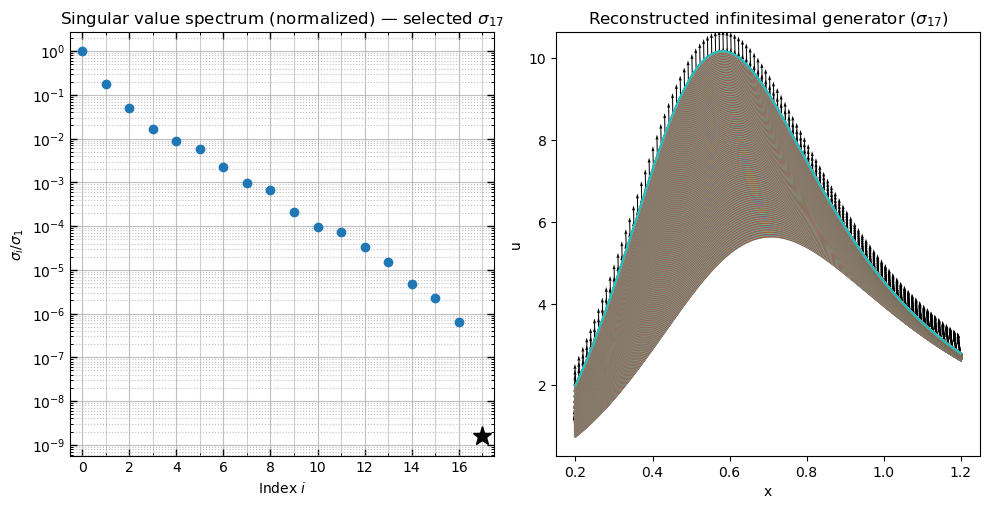

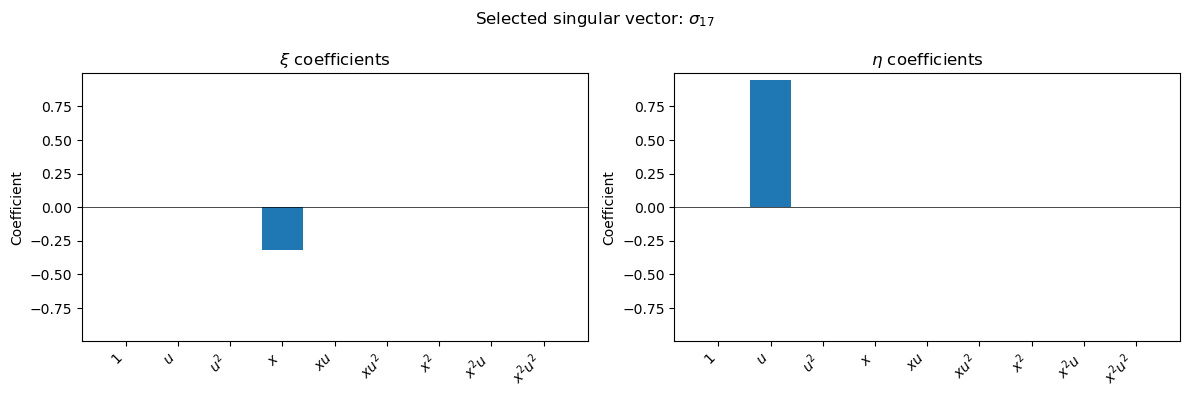

In [15]:
# Indexes into small_sv_idx, printed above (not an absolute S/Vt index).
# Out-of-range values are clamped to the nearest valid choice with a warning.
SV_CHOICE = 0
normalize_quiver = True
scale_quiver = 0.5

idx = solver.pick_small_singular_value(small_sv_idx, sv_choice=SV_CHOICE)
result = solver.select_singular_vector(svd_result, idx, characteristic=characteristic)
rpt.print_selection_summary(result.S, result.idx)

# Every plot below is derived from this one chosen singular vector.
sigma_label = rf"$\sigma_{{{result.idx}}}$"

# Same spectrum as above (fig3/ax3), on a new axis, with the chosen
# singular value starred.
fig4, ax4 = plt.subplots(1,2, figsize=(10, 6))

ax4[0].semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax4[0].semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax4[0].semilogy(result.idx, S_norm[result.idx], marker='*', markersize=14, linestyle='None', color='k', zorder=3)
ax4[0].set_xlabel("Index $i$")
ax4[0].set_ylabel(r"$\sigma_i / \sigma_1$")
ax4[0].set_title(f"Singular value spectrum (normalized) \u2014 selected {sigma_label}")
ax4[0].set_box_aspect(1)

# Linear x (integer SV indices), log10 y.
n_sv = len(svd_result.S)
ax4[0].set_xscale('linear')
ax4[0].set_yscale('log', base=10)
ax4[0].set_xlim(-0.5, n_sv - 0.5)

# x: dotted vertical grid at every index; solid/darker where ticks are labeled.
ax4[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True, min_n_ticks=4))
ax4[0].xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax4[0].xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax4[0].xaxis.get_major_formatter().set_scientific(False)

# y: solid grid at each decade; lighter log-paper lines between.
ax4[0].yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=15))
ax4[0].yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
)
ax4[0].yaxis.set_minor_formatter(mticker.NullFormatter())

ax4[0].tick_params(which='major', direction='in', top=True, right=True, length=5, width=1.0)
ax4[0].tick_params(which='minor', direction='in', top=True, right=True, length=2.5, width=0.7)

ax4[0].grid(which='minor', axis='x', linestyle='-', linewidth=0.8, alpha=0.6)
ax4[0].grid(which='major', axis='x', linestyle='-', linewidth=0.8, alpha=0.8)
ax4[0].grid(which='minor', axis='y', linestyle=':', linewidth=0.8, alpha=0.8)
ax4[0].grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.8)

if normalize_quiver:
    xy_norm = np.sqrt(result.xi**2 + result.eta**2)
    xy_norm[xy_norm == 0] = 1
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi / xy_norm, result.eta / xy_norm, angles='uv', scale=20)
elif scale_quiver < 1:
    ax4[1].quiver(X_stacked[0], X_stacked[1], scale_quiver*result.xi, scale_quiver*result.eta, angles='uv', scale=20)
else:
    ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi, result.eta, angles='xy', scale=20, scale_units='xy')

for trajectory in X:
    ax4[1].plot(trajectory[0], trajectory[1])
ax4[1].set_xlabel("x")
ax4[1].set_ylabel("u")
ax4[1].set_title(f"Reconstructed infinitesimal generator ($\\sigma_{{{result.idx}}}$)")
ax4[1].set_box_aspect(1)

fig4.tight_layout()

# Coefficients
n_basis = len(result.param_list)

bars_fig, (ax_xi, ax_eta) = plt.subplots(1, 2, figsize=(12, 4))
bars_fig.suptitle(f"Selected singular vector: {sigma_label}")
coeff_ylim = plot.shared_coefficient_ylim(result.singular_vector[:n_basis], result.singular_vector[n_basis:])
plot.plot_basis_coefficient_bars(
    result.singular_vector[:n_basis], result.param_list, basis_args.basis_type,
    ax=ax_xi, title=r"$\xi$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
plot.plot_basis_coefficient_bars(
    result.singular_vector[n_basis:], result.param_list, basis_args.basis_type,
    ax=ax_eta, title=r"$\eta$ coefficients", sort_by_magnitude=False, log_scale=False, ylim=coeff_ylim
)
bars_fig.tight_layout()

if characteristic:
    print(f"Plotting characteristic point symmetry Xhat = Q d/du, with Q = eta - u_x * xi. Scaled by {scale_quiver}")
else:
    print(f"Plotting point symmetry X = xi d/dx + eta d/du. Scaled by {scale_quiver}")


### Jet-space infinitesimal generator

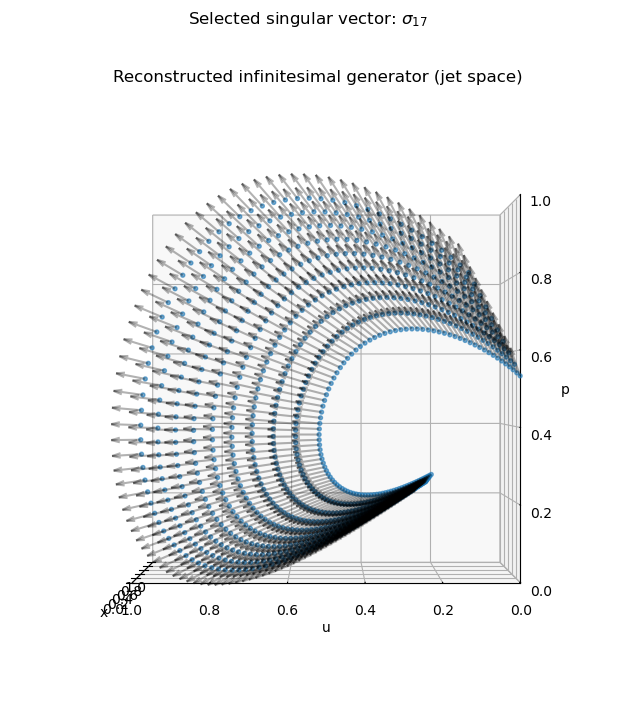

In [16]:
V = np.stack((result.xi, result.eta, result.zeta))

jet_fig, jet_ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(8, 8))
jet_fig.suptitle(f"Selected singular vector: {sigma_label}")
plot.scaled_3D_quiver(X_stacked, V, mode="tangent", ax=jet_ax)
jet_ax.set_title("Reconstructed infinitesimal generator (jet space)")
jet_ax.view_init(elev=0, azim=180, roll=0)
